<a href="https://colab.research.google.com/github/shreyashrodge83-create/EE-AIML-SEM-5-/blob/main/Task_10_EE561.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [3]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [4]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [5]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [6]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [7]:
import math

In [8]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [9]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=836810.5812353689
2/(50, error=3606982794201.3755
3/(50, error=1.2948442540196942e+19
4/(50, error=2.9294171052046578e+26
5/(50, error=1.0817466927255482e+34
6/(50, error=3.9871889398965324e+41
7/(50, error=1.4696301848983348e+49
8/(50, error=5.416881197733402e+56
9/(50, error=1.9965976619069282e+64
10/(50, error=7.35922032995714e+71
11/(50, error=2.712520649409589e+79
12/(50, error=9.998026888150297e+86
13/(50, error=3.68515320530126e+94
14/(50, error=1.358303423112184e+102
15/(50, error=5.006544060594767e+109
16/(50, error=1.8453522978868628e+117
17/(50, error=6.801747996424892e+124
18/(50, error=2.507043010694881e+132
19/(50, error=9.240660872437082e+139
20/(50, error=3.40599714464898e+147
21/(50, error=1.2554098358873631e+155
22/(50, error=4.627290596877918e+162
23/(50, error=1.7055640043492575e+170
24/(50, error=6.286505055235912e+177
25/(50, error=2.3171306212331295e+185
26/(50, error=8.540666504967574e+192
27/(50, error=3.147987587780271e+200
28/(50, error=1.1603105

/tmp/ipykernel_3204/430305362.py:21: RuntimeWarning: overflow encountered in scalar add
  error += mse(y,output)
/tmp/ipykernel_3204/2117857837.py:2: RuntimeWarning: overflow encountered in power
  return np.mean(np.power(y_true - y_pred, 2))
/tmp/ipykernel_3204/494197032.py:11: RuntimeWarning: invalid value encountered in multiply
  return np.multiply(output_gradient, self.activation_prime(self.input))


In [10]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]


In [11]:
import matplotlib.pyplot as plt

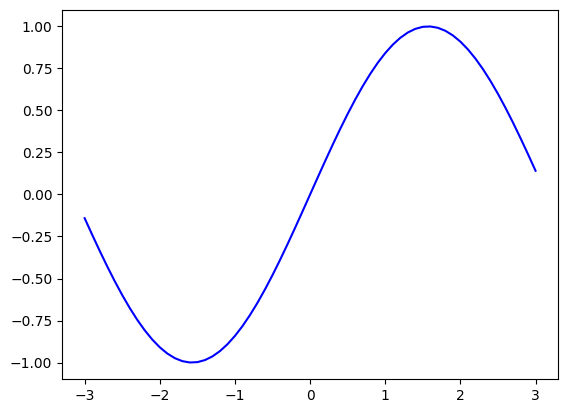

In [12]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [14]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [15]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.2729946903439748
2/(50, error=1.058349650399139
3/(50, error=0.9002223848208709
4/(50, error=0.8061170824112631
5/(50, error=0.6864221992124997
6/(50, error=0.6089357023304864
7/(50, error=0.5660695396596096
8/(50, error=0.5374270355667904
9/(50, error=0.5162000611068731
10/(50, error=0.499598182010869
11/(50, error=0.48604924594979665
12/(50, error=0.4745524260298812
13/(50, error=0.4644535932536895
14/(50, error=0.4553625310371939
15/(50, error=0.4471159092450987
16/(50, error=0.43962930058617716
17/(50, error=0.4328125715270522
18/(50, error=0.42655589987085474
19/(50, error=0.4207548708617038
20/(50, error=0.4153288226120675
21/(50, error=0.41022246925689887
22/(50, error=0.40542313368273214
23/(50, error=0.40093928908255955
24/(50, error=0.3967578875973033
25/(50, error=0.39285070780849507
26/(50, error=0.38919053017501737
27/(50, error=0.38575016201539336
28/(50, error=0.38250374831173656
29/(50, error=0.37943284965468865
30/(50, error=0.37652430333957027
31/(50, e

In [18]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [21]:
!pip install simple-colors

In [22]:
import simple_colors

In [23]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 8 	true: 4
pred: 1 	true: 1
pred: 3 	true: 4
pred: 8 	true: 9
pred: 6 	true: 5
pred: 7 	true: 9
pred: 0 	true: 0
pred: 6 	true: 6
pred: 7 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 7 	true: 9
pred: 7 	true: 7
pred: 2 	true: 3
pred: 6 	true: 4
Accuracy: 0.55
Correct: 11


In [24]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

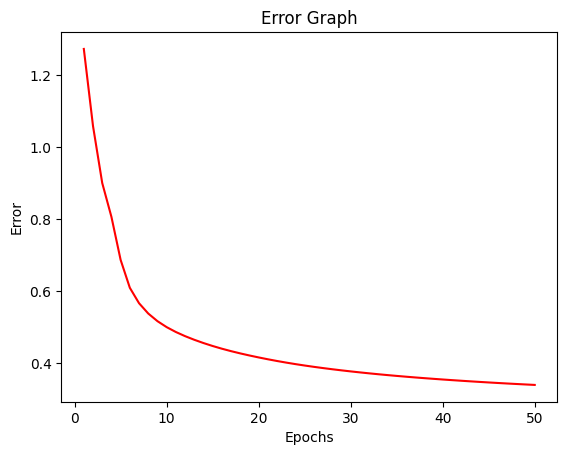

In [25]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()